In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True
)





In [15]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------
alpha = 0.2
gamma = 0.95

epsilon = 0.8
epsilon_min = 0.05
epsilon_decay = 0.997

num_episodes = 15000
max_steps = 1000


In [6]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros(
    (env.observation_space.n, env.action_space.n)
)

episode_rewards = []


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------
def epsilon_greedy_action(state, epsilon):

    if np.random.random() < epsilon:
        # Exploration
        return env.action_space.sample()

    else:
        # Exploitation
        return np.argmax(Q[state])





In [7]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------


for episode in range(num_episodes):

    state, info = env.reset()
    total_reward = 0

    for step in range(max_steps):

        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-Learning update
        best_next_value = np.max(Q[next_state])

        Q[state, action] = Q[state, action] + alpha * (
            reward
            + gamma * best_next_value
            - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    episode_rewards.append(total_reward)

    # Reduce exploration gradually
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )






In [11]:
# -------------------------------------------------
# State-Value Function
# -------------------------------------------------
state_values = np.max(Q, axis=1)


In [17]:
# -------------------------------------------------
# Learned Policy
# -------------------------------------------------
learned_policy = np.argmax(Q, axis=1)

In [18]:

# -------------------------------------------------
# Display Functions
# -------------------------------------------------
def print_value_function(values):

    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):

    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [16]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

# Calculate state values and learned policy from the Q-table
state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)



Final Q-table:
[[0.157 0.113 0.107 0.106]
 [0.055 0.076 0.083 0.099]
 [0.1   0.096 0.095 0.095]
 [0.067 0.069 0.061 0.088]
 [0.188 0.104 0.095 0.045]
 [0.    0.    0.    0.   ]
 [0.09  0.084 0.051 0.046]
 [0.    0.    0.    0.   ]
 [0.081 0.124 0.154 0.259]
 [0.144 0.368 0.196 0.257]
 [0.435 0.181 0.19  0.097]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.268 0.178 0.643 0.282]
 [0.449 0.728 0.577 0.499]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.157 0.099 0.1   0.088]
 [0.188 0.    0.09  0.   ]
 [0.259 0.368 0.435 0.   ]
 [0.    0.643 0.728 0.   ]]

Learned Policy:
[['L' 'U' 'L' 'U']
 ['L' 'L' 'L' 'L']
 ['U' 'D' 'L' 'L']
 ['L' 'R' 'D' 'L']]

Average reward over last 1000 episodes: 0.412


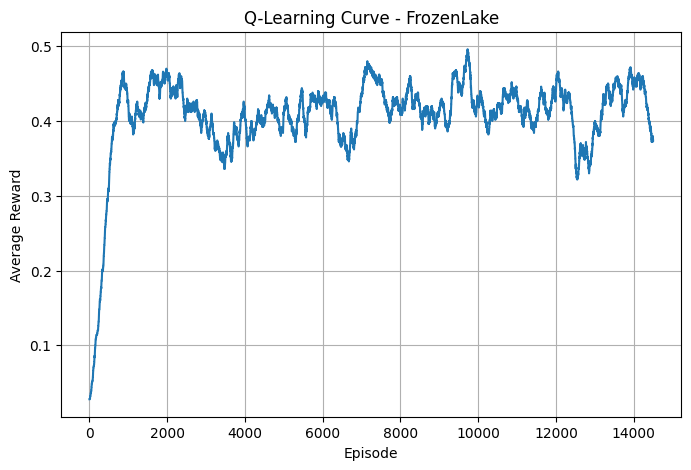

In [19]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()